In [134]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Questão 1 - EDA

#### Cenário

Antes de qualquer análise, modelagem ou tomada de decisão, é fundamental entender o que existe nos dados. O Sr. Almir quer uma resposta simples: “Posso confiar nesses dados para tomar decisões?”

Sua missão é **realizar uma análise exploratória inicial** do dataset vendas_2023_2024.csv e responder perguntas básicas, porém críticas, sobre volume, distribuição e qualidade dos dados.

**Premissas obrigatórias**  
Utilize apenas o dataset vendas_2023_2024.csv  
Não faça limpeza nem tratamento dos dados  
Apenas observe, agregue e descreva  

**Tarefas:**   
*Parte 1* — Visão geral do dataset   
Informe:
- Quantidade total de linhas  
- Quantidade total de colunas  
- Intervalo de datas analisado (data mínima e máxima)

*Parte 2* — Análise de valores numéricos

Para a coluna "total", calcule:  
- Valor mínimo
- Valor máximo
- Valor médio

*Parte 3* — Interpretação  
Responda de forma resumida:   
Com base na análise exploratória realizada, escreva um breve diagnóstico sobre a confiabilidade do dataset vendas_2023_2024.csv para análises futuras.  
Comente sobre:  
- possíveis outliers em "total",
- qualidade dos dados (valores nulos ou inconsistentes),
- e se você considera que o dataset está pronto para análises ou se exigiria tratamento prévio.

In [3]:
# Impportação do arquivo

df_vendas = pd.read_csv("raw_data/vendas_2023_2024.csv")

In [4]:
# Checagem inicial

df_vendas.shape
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 464.0+ KB


In [5]:
# Checagem de linhas vazias

raw = pd.read_csv("raw_data/vendas_2023_2024.csv", skip_blank_lines=False)

# detectar linhas totalmente vazias
empty_rows = raw.isnull().all(axis=1).sum()

empty_rows

6

**Insight**: O dataset original contém 6 linhas completamente vazias, que são automaticamente ignoradas pelo Pandas durante a leitura, mas representam inconsistência estrutural no arquivo bruto.

In [6]:
# Checagem das colunas

df_vendas.columns

Index(['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date'], dtype='object')

In [7]:
# Checagem de datas

df_vendas["sale_date"].head(20)

0     2023-09-10
1     15-09-2024
2     2024-08-13
3     2023-02-03
4     2024-02-12
5     2023-09-26
6     2024-02-28
7     07-11-2023
8     2024-08-25
9     2023-05-07
10    29-07-2024
11    28-04-2024
12    06-05-2024
13    2023-10-14
14    07-10-2024
15    2023-09-05
16    2024-11-28
17    2023-07-16
18    27-11-2024
19    04-12-2024
Name: sale_date, dtype: object

In [8]:
# Checagem de formato de datas

print('Formato YYYY-MM-DD: ', df_vendas["sale_date"].str.contains(r"\d{4}-\d{2}-\d{2}").sum())
print('Formato DD-MM-YYYY: ', df_vendas["sale_date"].str.contains(r"\d{2}-\d{2}-\d{4}").sum())
print('Outros formatos: ', df_vendas["sale_date"][~df_vendas["sale_date"].str.contains(f"{r"\d{4}-\d{2}-\d{2}"}|{r"\d{2}-\d{2}-\d{4}"}", na=False)].sum())

Formato YYYY-MM-DD:  4913
Formato DD-MM-YYYY:  4982
Outros formatos:  0


In [9]:
check_dates = pd.to_datetime(df_vendas["sale_date"], errors="coerce")

print('Total de datas inválidas: ', check_dates.isna().sum())

Total de datas inválidas:  4982


In [10]:
# Checagem do range de datas

# 1. Série com as datas em formato ISO (YYYY-MM-DD)
s_iso = df_vendas.loc[df_vendas["sale_date"].str.contains(r"\d{4}-\d{2}-\d{2}"), "sale_date"]
serie_iso = pd.to_datetime(s_iso)

# 2. Série com as datas em formato BR (DD-MM-YYYY)
# Aqui usamos o parâmetro 'dayfirst=True' para o Pandas não se perder
s_br = df_vendas.loc[df_vendas["sale_date"].str.contains(r"\d{2}-\d{2}-\d{4}"), "sale_date"]
serie_br = pd.to_datetime(s_br, dayfirst=True)

# 3. União das duas séries em uma única série de diagnóstico (O combine_first() preenche os buracos de uma com a outra)
datas_validadas = serie_iso.combine_first(serie_br)

# ---Analisando o Range de datas ---

print(f"Total de registros processados: {len(datas_validadas)}")
print(f"Data Mínima: {datas_validadas.min()}")
print(f"Data Máxima: {datas_validadas.max()}")
print(f"Total de NaT (Falhas): {datas_validadas.isna().sum()}")

Total de registros processados: 9895
Data Mínima: 2023-01-01 00:00:00
Data Máxima: 2024-12-31 00:00:00
Total de NaT (Falhas): 0


**Insight**: A coluna de datas apresenta inconsistência de formatação, com registros nos padrões DD-MM-YYYY e YYYY-MM-DD. Essa falta de padronização impede a conversão direta e confiável para o tipo datetime, o que compromete análises temporais sem tratamento prévio.

No entanto, ao realizar uma conversão controlada apenas para fins de validação, observa-se que as datas cobrem integralmente o período de 2023 a 2024, sem indícios de registros fora do intervalo esperado. Isso sugere que, apesar da inconsistência de formato, os valores em si são potencialmente válidos.

In [11]:
# Checando a coluna "total"

print(f'Valor Mínimo:  {df_vendas["total"].min():.2f}')
print(f'Valor Máximo:  {df_vendas["total"].max():.2f}')
print(f'Valor Médio:  {df_vendas["total"].mean():.2f}')
print(f'Valor Mediano:  {df_vendas["total"].median():.2f}')

Valor Mínimo:  294.50
Valor Máximo:  2222973.00
Valor Médio:  263797.83
Valor Mediano:  82225.00


In [12]:
pd.options.display.float_format = '{:,.2f}'.format

df_vendas["total"].describe()

count       9,895.00
mean      263,797.83
std       390,007.18
min           294.50
25%        23,138.20
50%        82,225.00
75%       339,094.50
max     2,222,973.00
Name: total, dtype: float64

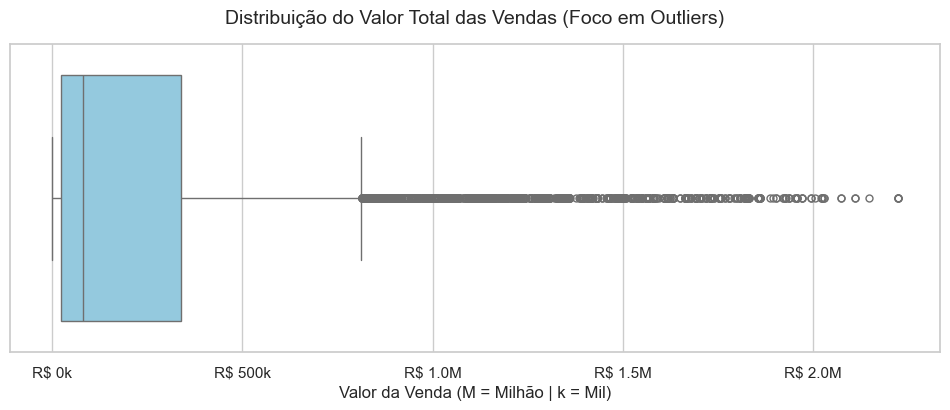

In [16]:
# Boxplot para visualização da distribuição de valores

# Tamanho da imagem
plt.figure(figsize=(12, 4))

# Cria o boxplot
sns.set_theme(style="whitegrid")
ax = sns.boxplot(x=df_vendas["total"], color="skyblue", fliersize=5)

# Formatação dos valores no eixo
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x/1e6:.1f}M' if x >= 1e6 else f'R$ {x/1e3:.0f}k'))

# Título do gráfico e dos eixos
plt.title("Distribuição do Valor Total das Vendas (Foco em Outliers)", fontsize=14, pad=15)
plt.xlabel("Valor da Venda (M = Milhão | k = Mil)", fontsize=12)

plt.show()

In [19]:
# Check de outliers estatísticos

Q1 = df_vendas["total"].quantile(0.25)
Q3 = df_vendas["total"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df_vendas[df_vendas["total"] > upper_bound].shape

(1018, 6)

**Insight**: A análise de distribuição e o boxplot da coluna "total" evidenciam uma distribuição fortemente assimétrica à direita, com a maior parte das vendas concentrada abaixo de aproximadamente R\\$ 400 mil e mediana próxima de R\\$ 82 mil.

Observa-se também a presença de diversos valores acima do limite superior do boxplot (1.5×IQR), que são classificados como outliers sob o ponto de vista estatístico. No entanto, a frequência e o padrão desses valores (1818 das 9895 observações, ou aproximadamente 10%) indicam que eles não representam necessariamente anomalias, mas sim vendas legítimas de alto valor, possivelmente associadas a produtos de maior preço unitário e compras em volume.

Esse comportamento sugere a existência de diferentes perfis de venda dentro do dataset, indicando que análises futuras podem se beneficiar de uma segmentação por faixa de valor, a fim de capturar melhor as dinâmicas entre vendas de menor e maior porte.

### Resposta

**Diagnóstico de confiabilidade do dataset:**

A análise inicial indica que o dataset possui volume consistente de registros e cobertura temporal adequada, contemplando integralmente o período de 2023 a 2024. No entanto, foram identificadas algumas inconsistências estruturais que impactam sua utilização direta sem tratamento prévio.

Primeiramente, o arquivo original contém linhas completamente vazias, o que evidencia falhas no processo de geração ou manutenção dos dados. Além disso, a coluna de datas apresenta múltiplos formatos (DD-MM-YYYY e YYYY-MM-DD), impedindo sua conversão direta para o tipo datetime e comprometendo análises temporais sem padronização.

A variável "total" apresenta boa consistência estrutural, sem valores nulos ou negativos, e com tipagem adequada para análise. Observa-se, entretanto, uma distribuição fortemente assimétrica à direita, com presença de valores elevados. Embora esses valores sejam classificados como outliers sob o ponto de vista estatístico, sua frequência e padrão indicam que representam vendas legítimas de alto valor, e não inconsistências ou erros nos dados.

De forma geral, o dataset demonstra potencial analítico e apresenta dados coerentes com o contexto de negócio. Não pode ser considerado totalmente confiável, porém, em seu estado bruto, sendo necessária uma etapa prévia de limpeza e padronização antes de sua utilização em análises mais avançadas.

|    
--------------------------------------------------------------------------------------------------- // ---------------------------------------------------------------------------------------------------  
|

## Questão 2 - Produtos

**Cenário**

Gabriel percebeu que seus dados estão desorganizados e sem um padrão definido e isso pode tornar o trabalho de análise mais trabalhoso. Precisamos melhorar isso utilizando o Python.

Sua missão é realizar uma normalização dos dados presentes no arquivo produtos_raw.csv.

**Premissas obrigatórias**  
Utilize apenas o CSV produtos_raw.csv
Utilize obrigatoriamente Python 3

**Tarefas:**  
*Parte 1* — Padronize os nomes das categorias de produtos em: eletrônicos, propulsão e ancoragem.  
*Parte 2* — Converta os valores para o tipo numérico.  
*Parte 3* — Remova as duplicatas.

In [42]:
# Impportação do arquivo

df_produtos = pd.read_csv("raw_data/produtos_raw.csv")

In [22]:
df_produtos.head()

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz


In [23]:
df_produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             157 non-null    object
 1   price            157 non-null    object
 2   code             157 non-null    int64 
 3   actual_category  157 non-null    object
dtypes: int64(1), object(3)
memory usage: 5.0+ KB


In [25]:
# Checagem das categorias

print(sorted(df_produtos['actual_category'].unique()))

['A N C O R A G E M', 'ANCORAGEM', 'AnCoRaGeM', 'AncorageM', 'Ancoragem', 'Ancoragen', 'Ancoraguem', 'AncorajeM', 'Ancorajem', 'Ancorajen', 'Ancorajm', 'E L E T R Ô N I C O S', 'ELETRONICOS', 'ELEtRÔNICOS', 'Eletronicos', 'Eletronicoz', 'Eletroniscos', 'Eletrunicos', 'EletrônicoS', 'Eletrônicos', 'Encoragem', 'Encoragi', 'P R O P U L S Ã O', 'PROPULSAO', 'PrOpUlSãO', 'Prop', 'Propulsam', 'Propulssão', 'Propulçao', 'Propulção', 'Propução', 'aNcOrAgEm', 'ancoragem', 'eLeTrÔnIcOs', 'eletronicos', 'eletrônicos', 'pRoPuLsÃo', 'propulsao', 'propulsão']


=> As categorias aparecem escritas de 39 maneiras distintas.

In [43]:
# Função que mapeia as distintas escritas e atribui a escrita correta

def mapear_categoria(valor):
    # Remove espaços (inclusive entre letras) e converte para minúsculas
    normalizado = valor.replace(' ', '').lower()
    
    if 'eletr' in normalizado:
        return 'eletrônicos'
    elif 'prop' in normalizado:
        return 'propulsão'
    elif 'ncora' in normalizado:
        return 'ancoragem'
    else:
        return None

# Aplicando a função na coluna

df_produtos['actual_category'] = df_produtos['actual_category'].apply(mapear_categoria)

In [45]:
# Checando a coluna após a padronização

print(df_produtos['actual_category'].unique())
print(df_produtos['actual_category'].isna().sum())

['eletrônicos' 'propulsão' 'ancoragem']
0


In [49]:
# Checando os valores na coluna 'price'

print(df_produtos['price'].dtype)
print(df_produtos['price'].head())

object
0    R$ 33122.52
1    R$ 13998.15
2     R$ 9024.19
3     R$ 3381.88
4    R$ 23669.01
Name: price, dtype: object


=> Valores classificados como objeto (string), devido à inclusão dos 3 primeiros caracteres, "R$ "

In [50]:
# Removendo os 3 primeiros caracteres e convertendo a coluna para o tipo float

df_produtos['price'] = df_produtos['price'].str[3:].astype(float)

In [51]:
# Checando a coluna após a mudança

print(df_produtos['price'].dtype)
print(df_produtos['price'].head())

float64
0   33,122.52
1   13,998.15
2    9,024.19
3    3,381.88
4   23,669.01
Name: price, dtype: float64


In [52]:
# Sanity Check da nova coluna

print(f"Mínimo: {df_produtos['price'].min()}")
print(f"Máximo: {df_produtos['price'].max()}")
print(f"Valores nulos: {df_produtos['price'].isna().sum()}")
print(f"Valores negativos: {(df_produtos['price'] < 0).sum()}")

Mínimo: 309.54
Máximo: 148198.23
Valores nulos: 0
Valores negativos: 0


In [57]:
# Checando duplicatas

print('Linhas totais: ', df_produtos.count())
print('Linhas únicas: ', df_produtos.nunique())

Linhas totais:  name               157
price              157
code               157
actual_category    157
dtype: int64
Linhas únicas:  name               150
price              150
code               150
actual_category      3
dtype: int64


In [58]:
df_produtos.value_counts().head(10)

name                                            price       code  actual_category
Motor Diesel Yanmar Velocity 37HP               102,221.97  62    propulsão          4
Boia de Arqueamento Delta Nexus                 4,349.86    145   ancoragem          3
Cabo de Nylon Delta Velocity Core Mako          1,549.35    127   ancoragem          2
GPS Lowrance Evo Storm Drift                    6,067.71    37    eletrônicos        2
Boia de Arqueamento Bruce Barracuda             2,214.14    144   ancoragem          1
Motor de Popa Yamaha Evo Dash 155HP             121,534.82  54    propulsão          1
Motor de Popa Yamaha Mako 108HP                 85,789.05   67    propulsão          1
Motor de Popa Yamaha Thrust Marlin Nexus 182HP  79,097.33   90    propulsão          1
Piloto Automático AIS Core                      14,258.56   28    eletrônicos        1
Piloto Automático Furuno Core Boost Flux        17,283.18   26    eletrônicos        1
Name: count, dtype: int64

=> Total de 7 linhas duplicadas

In [59]:
# Eliminando linhas duplicadas

df_produtos = df_produtos.drop_duplicates()

In [62]:
# Checando novo dataframe

print(df_produtos.shape)
print(df_produtos.info)

(150, 4)
<bound method DataFrame.info of                                           name     price  code actual_category
0                  Transponder AIS Maré Magnum 33,122.52     1     eletrônicos
1                    Transponder Furuno Marlin 13,998.15     2     eletrônicos
2                 Radar Furuno Pulse Leviathan  9,024.19     3     eletrônicos
3                    Rádio AIS Hydro Tidal Zen  3,381.88     4     eletrônicos
4               Piloto Automático Furuno Storm 23,669.01     5     eletrônicos
..                                         ...       ...   ...             ...
152                     Corrente Delta Vox Ion    495.98   146       ancoragem
153  Corrente Danforth Force Leviathan Impulse  3,030.08   147       ancoragem
154          Âncora Delta Force Barracuda Mako  4,785.56   148       ancoragem
155                   Cabo de Nylon Bruce Core  1,163.62   149       ancoragem
156          Cabo de Nylon Danforth Magnum Vox  1,645.66   150       ancoragem

[150 rows 

In [63]:
# Exportando para um novo arquivo csv

df_produtos.to_csv('produtos_cleaned.csv', index=False)

## Questão 3 - Custos de Importação

**Cenário**

Além dos dados de produtos, Gabriel percebeu também que o arquivo custos_importacao.json tem todos os dados históricos dos preços de compra aninhados num único campo. Para facilitar a análise dessa informação no banco de dados é necessário melhorarmos isso.



**Premissas obrigatórias**  
Utilize apenas o JSON custos_importacao.json   
Utilize obrigatoriamente Python 3   

**Tarefa:**  
- Carregue o arquivo JSON e gere um novo arquivo CSV organizando-o de acordo com a definição na imagem abaixo.

In [67]:
import json

# Convertendo o arquivo JSON "custos_importacao" para dataframe

rows = []

with open(r'raw_data\JSON\custos_importacao.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

for product in data:
    for hist in product['historic_data']:
        rows.append({
            'product_id': product['product_id'],
            'product_name': product['product_name'],
            'category': product['category'],
            'start_date': hist['start_date'],
            'usd_price': hist['usd_price']
        })

df_costs = pd.DataFrame(rows)

In [68]:
# Checando tipos das colunas

df_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1260 non-null   int64  
 1   product_name  1260 non-null   object 
 2   category      1260 non-null   object 
 3   start_date    1260 non-null   object 
 4   usd_price     1260 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 49.3+ KB


=> Coluna de datas precisa ser convertida

In [70]:
df_costs['start_date'].head(10)

0    10/08/2016
1    15/06/2018
2    25/09/2018
3    19/03/2019
4    17/01/2020
5    17/06/2020
6    02/07/2021
7    16/05/2022
8    28/02/2023
9    17/10/2023
Name: start_date, dtype: object

=> Datas no formato DD/MM/YYYY não foram convertidas automaticamente

In [71]:
# Convertendo a coluna de datas

df_costs['start_date'] = pd.to_datetime(df_costs['start_date'], dayfirst=True)

In [72]:
# Checando a nova coluna

print(df_costs['start_date'].dtype) 
print(df_costs['start_date'].head())

datetime64[ns]
0   2016-08-10
1   2018-06-15
2   2018-09-25
3   2019-03-19
4   2020-01-17
Name: start_date, dtype: datetime64[ns]


In [73]:
# Exportando para arquivo CSV

df_costs.to_csv('custos_importacao.csv', index=False)

## Questão 4 - Dados Públicos  

**Cenário**  

O Sr. Almir identificou que alguns produtos podem ter sido vendidos abaixo do custo, possivelmente por erro operacional.

O problema é que:  
- O sistema de vendas (vendas_2023_2024.csv) registra valores em real BRL
- O catálogo de fornecedores (custos_importacao.json) registra custos unitários em dollar USD
- O câmbio varia diariamente  
Até hoje, ninguém cruzou o custo em dólar do dia da venda com o valor de venda em reais.
Sua missão é abrir essa “caixa preta” financeira e identificar onde houve prejuízo real.

Premissas obrigatórias:  
- O custo em USD é unitário
- O custo em BRL deve ser calculado usando o câmbio da data da venda
- A taxa de câmbio deve ser considerada a média da cotação de venda do dia (Banco Central)
- A receita total do produto considera todas as vendas (inclusive as sem prejuízo)
- Ignore impostos e frete

**Tarefas:**  
*Parte 1* — Cálculo e modelagem 
- Calcule o custo total em BRL por transação
- Identifique transações com prejuízo
- Agregue os dados por id_produto, gerando:
    - Receita total (BRL)
    - Prejuízo total (BRL)
    - Percentual de perda (prejuízo_total / receita_total)  
    
*Parte 2* — Análise visual  
Gere um gráfico que represente o prejuízo total por produto, considerando apenas produtos que tiveram prejuízo. (Inserir o gráfico no relatório/dashboard final)  

*Parte 3* —  Explique sobre o desenvolvimento :  
- Qual data de câmbio você utilizou?
- Como definiu o prejuízo?
- Alguma suposição relevante?

In [135]:
# Criando um dataframe com a cotação diária do dólar

import pandas as pd
import requests

# Código 10813: Dólar comercial (venda) - diário
serie_id = 10813
data_inicio = '29/12/2022'
data_fim = '03/01/2025'

# URL da API do Banco Central (SGS)
url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{serie_id}/dados?formato=json&dataInicial={data_inicio}&dataFinal={data_fim}'

# Puxando os dados
response = requests.get(url)
data = response.json()

# Criando o DataFrame
df_cambio = pd.DataFrame(data)

# Tratamento de tipos e nomes de colunas
df_cambio['data'] = pd.to_datetime(df_cambio['data'], dayfirst=True)
df_cambio['valor'] = df_cambio['valor'].astype(float)

df_cambio.columns = ['date', 'usd_to_brl']

In [137]:
# Preenchendo o dataframe com os dias não úteis, utilizando o método forward fill

# Cria um índice com todos os dias do período
todos_os_dias = pd.date_range(start=df_cambio['date'].min(), end=df_cambio['date'].max(), freq='D')

# Reindexa o dataframe com todos os dias e preenche os vazios com forward fill
df_cambio = df_cambio.set_index('date').reindex(todos_os_dias).ffill().reset_index()
df_cambio.columns = ['date', 'usd_to_brl']

In [138]:
df_cambio.head(15)

,date,usd_to_brl
0,2022-12-29,5.22
1,2022-12-30,5.22
2,2022-12-31,5.22
3,2023-01-01,5.22
4,2023-01-02,5.34
5,2023-01-03,5.38
6,2023-01-04,5.45
7,2023-01-05,5.40
8,2023-01-06,5.28
9,2023-01-07,5.28


In [139]:
print(df_cambio.shape)
print(df_cambio.isna().sum())

(737, 2)
date          0
usd_to_brl    0
dtype: int64


In [140]:
# Criando dataframe para a planilha produtos

df_produtos = pd.read_csv("produtos_cleaned.csv")

df_produtos.head()

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,"33,122.52",1,eletrônicos
1,Transponder Furuno Marlin,"13,998.15",2,eletrônicos
2,Radar Furuno Pulse Leviathan,"9,024.19",3,eletrônicos
3,Rádio AIS Hydro Tidal Zen,"3,381.88",4,eletrônicos
4,Piloto Automático Furuno Storm,"23,669.01",5,eletrônicos


In [141]:
# Criando dataframe para a planilha custos de importaçãoo

df_custos = pd.read_csv("custos_importacao.csv")

df_custos.head()

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,"10,583.63"
1,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,"8,778.36"
2,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,"8,023.87"
3,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,"8,772.78"
4,1,Transponder AIS Maré Magnum,eletrônicos,2020-01-17,"7,918.18"


In [142]:
df_custos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1260 non-null   int64  
 1   product_name  1260 non-null   object 
 2   category      1260 non-null   object 
 3   start_date    1260 non-null   object 
 4   usd_price     1260 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 49.3+ KB


In [143]:
# Convertendo a coluna de datas

df_custos['start_date'] = pd.to_datetime(df_custos['start_date'])

df_custos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    1260 non-null   int64         
 1   product_name  1260 non-null   object        
 2   category      1260 non-null   object        
 3   start_date    1260 non-null   datetime64[ns]
 4   usd_price     1260 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 49.3+ KB


In [144]:
# Criando dataframe para planilha de vendas

df_vendas = pd.read_csv("raw_data/vendas_2023_2024.csv")

print(df_vendas.shape)
df_vendas.head()

(9895, 6)


,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,"3,405.00",2023-09-10
1,1,3,136,9,"16,873.90",15-09-2024
2,2,25,139,7,"9,475.30",2024-08-13
3,4,20,23,5,"55,893.00",2023-02-03
4,5,8,57,4,"451,403.90",2024-02-12


In [145]:
# Corrigindo a coluna de datas

df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], dayfirst=True, format='mixed')

In [146]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 464.0 KB


In [147]:
df_cambio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737 entries, 0 to 736
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        737 non-null    datetime64[ns]
 1   usd_to_brl  737 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.6 KB


In [156]:
# Garantindo que as datas estão em ordem

df_vendas = df_vendas.sort_values('sale_date')
df_custos = df_custos.sort_values('start_date')
df_cambio = df_cambio.sort_values('date')

In [157]:
# Criando um dataframe que faz o merge entre 'vendas' e 'custos' com o custo vigente na data de cada venda

df = pd.merge_asof(
    df_vendas,
    df_custos[['product_id', 'start_date', 'usd_price']],
    left_on='sale_date',
    right_on='start_date',
    left_by='id_product',
    right_by='product_id',
    direction='backward'
)

In [158]:
df.head(10)

,id,id_client,id_product,qtd,total,sale_date,product_id,start_date,usd_price
0,1230,17,91,4,"512,566.80",2023-01-01,91,2022-03-16,"26,303.31"
1,8211,14,67,3,"257,367.00",2023-01-01,67,2022-06-17,"16,720.73"
2,666,14,15,5,"132,524.05",2023-01-01,15,2022-12-06,"5,325.40"
3,5256,19,78,12,"1,461,139.00",2023-01-01,78,2022-10-14,"23,053.04"
4,3549,10,53,13,"662,886.25",2023-01-01,53,2022-07-19,"9,958.63"
5,7765,30,22,2,"74,960.70",2023-01-01,22,2022-08-22,"7,630.67"
6,4294,7,44,5,"51,332.30",2023-01-01,44,2022-01-17,"1,963.02"
7,4212,9,96,6,"402,538.75",2023-01-01,96,2022-09-30,"13,063.42"
8,3131,28,130,13,"53,873.00",2023-01-01,130,2021-03-22,749.89
9,2300,30,95,9,"596,858.40",2023-01-01,95,2022-11-23,"12,945.63"


In [159]:
# Buscando a cotação do dólar na data de venda

df = pd.merge_asof(
    df,
    df_cambio,
    left_on='sale_date',
    right_on='date',
    direction='backward'
)

In [160]:
# Criando colunas que calculam o custo de venda

df['custo_unitario_brl'] = df['usd_price'] * df['usd_to_brl']
df['custo_total_brl'] = df['custo_unitario_brl'] * df['qtd']

In [161]:
# A coluna 'custo_total_brl' indica o custo, em Reais, por transação

df['custo_total_brl'].describe()

count       9,895.00
mean      277,786.78
std       419,409.72
min           312.13
25%        23,756.97
50%        85,185.74
75%       351,445.07
max     2,674,196.32
Name: custo_total_brl, dtype: float64

In [162]:
# Criando coluna de lucro e indicando prejuízo

df['lucro'] = df['total'] - df['custo_total_brl']
df['prejuizo'] = df['lucro'] < 0

# Prejuízo será uma coluna booleana, com True para transações com prejuízo

In [163]:
# Checando o total de transações com prejuízo

print(f"Transações com prejuízo: {df['prejuizo'].sum()}")
print(f"Total de transações: {len(df)}")

Transações com prejuízo: 6167
Total de transações: 9895


In [164]:
# Dataframe agregando por produto

df_por_produto = df.groupby('id_product').agg(           # agregação por produto
    receita_total=('total', 'sum'),                      # calcula receita total
    lucro_total=('lucro', 'sum')                         # calcula o lucro total
).reset_index()

# Cálculo da porcentagem
df_por_produto['percentual_perda'] = (df_por_produto['lucro_total'] / df_por_produto['receita_total'] * 100).round(2)

print(df_por_produto.sort_values('lucro_total').head(10))

    id_product  receita_total    lucro_total  percentual_perda
71          72  63,057,815.65 -39,809,090.51            -63.13
82          83  44,377,440.00 -18,607,005.07            -41.93
73          74  59,764,356.15  -6,341,763.58            -10.61
70          71  81,567,066.65  -5,788,013.22             -7.10
54          55  61,224,375.00  -5,360,513.40             -8.76
90          91  66,829,268.70  -4,623,929.86             -6.92
62          63  68,817,185.90  -4,465,281.14             -6.49
77          78  58,043,733.35  -3,945,525.31             -6.80
95          96  27,227,868.90  -2,608,310.55             -9.58
59          60  53,418,532.00  -2,155,648.51             -4.04


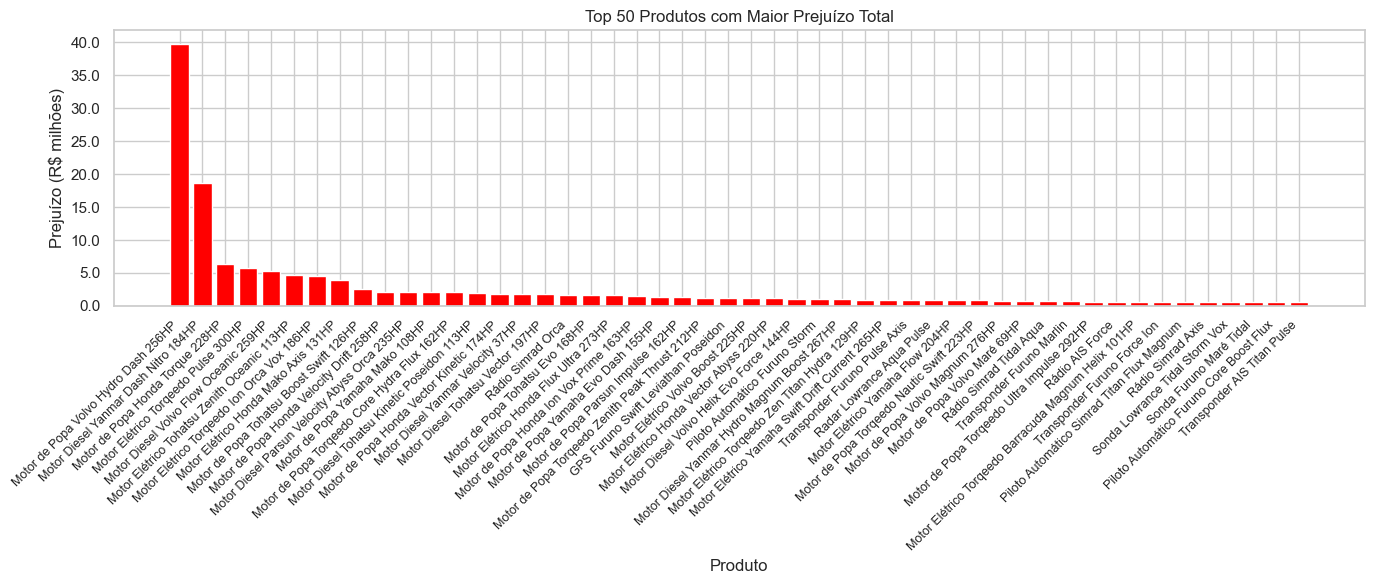

In [173]:
# Gráfico de prejuízo por produto

import matplotlib.pyplot as plt

# Apenas produtos que tiveram prejuízo
df_prejuizo = df_por_produto[df_por_produto['lucro_total'] < 0].sort_values('lucro_total')

# Trazendo o nome do produto
df_prejuizo = df_prejuizo.merge(
    df_produtos[['code', 'name']],
    left_on='id_product',
    right_on='code',
    how='left')

# Filtrando apenas os top 20 maiores prejuízos e inverte o sinal
df_top_prejuizo = df_prejuizo.nsmallest(50, 'lucro_total').copy()
df_top_prejuizo['prejuizo_positivo'] = df_top_prejuizo['lucro_total'].abs()

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(df_top_prejuizo['name'], df_top_prejuizo['prejuizo_positivo'], color='red')

ax.set_title('Top 50 Produtos com Maior Prejuízo Total')
ax.set_xlabel('Produto')
ax.set_ylabel('Prejuízo (R$ milhões)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}'))

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('top50_prejuizo_por_produto.png', dpi=150, bbox_inches='tight')
plt.show()

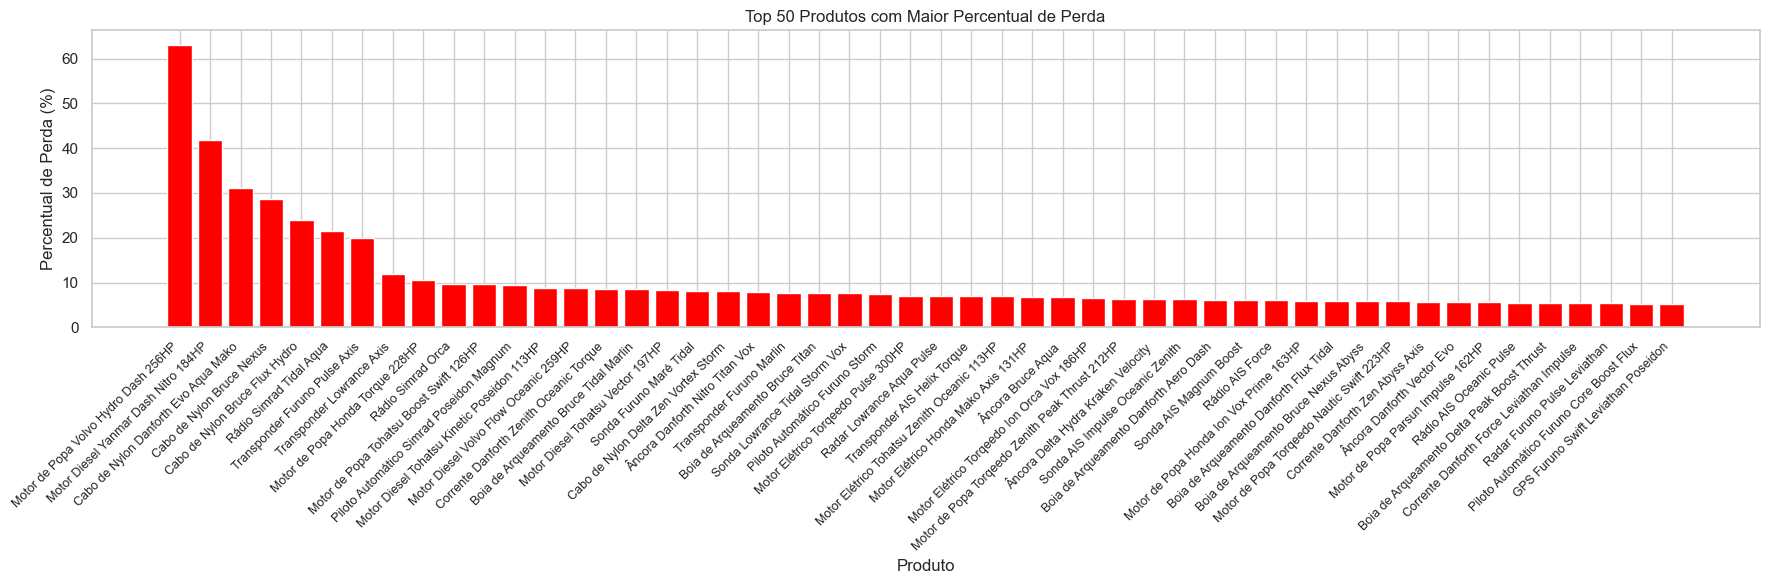

In [174]:
# Gráfico da perda em porcentagem

df_top_percentual = df_prejuizo.nsmallest(50, 'percentual_perda').copy()

fig, ax = plt.subplots(figsize=(18, 6))

ax.bar(df_top_percentual['name'], df_top_percentual['percentual_perda'].abs(), color='red')

ax.set_title('Top 50 Produtos com Maior Percentual de Perda')
ax.set_xlabel('Produto')
ax.set_ylabel('Percentual de Perda (%)')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('top50_percentual_perda_por_produto.png', dpi=150, bbox_inches='tight')
plt.show()

## Questão 5 - Análise de clientes

**Cenário**

A Diretoria da LH Nautical deseja identificar os clientes fieis. Diferente de quem compra muito uma única vez, o cliente fiel é o cliente que possui um gasto médio alto por transação e navega por diversas categorias da loja. O objetivo é mapear o que esses clientes de elite estão consumindo para replicar o comportamento em outros segmentos.


**Premissas obrigatórias:**  
- Faturamento Total: Soma da coluna total por cliente.
- Frequência: Contagem total de transações (IDs de venda) por cliente.
- Ticket Médio: Faturamento Total / Frequência.
- Diversidade de Categorias: Quantidade de categorias distintas que o cliente comprou.
- Nota: É necessário limpar os nomes das categorias no arquivo produtos_raw.csv (ex: consolidar "Ancorajen", "Encoragem" e "Ancoragem" como uma única categoria).
- Filtro de Elite: Apenas clientes que compraram produtos de 3 ou mais categorias distintas devem ser considerados no ranking.
- Desempate: Em caso de empate no Ticket Médio, utilize o id_cliente em ordem crescente.

**Tarefa:**
- Realize a limpeza das categorias de produtos para evitar duplicidade por erro de grafia.
- Calcule o Ticket Médio e a Diversidade de Categorias para cada id_cliente.
- Filtre os 10 clientes com o maior Ticket Médio que atendam ao critério de diversidade (3+ categorias).
- Para este grupo específico de 10 clientes, identifique qual categoria de produto concentra a maior quantidade total de itens comprados (sum(qtd)).

In [175]:
# Criando dataframe para a planilha clientes

df_clientes = pd.read_csv("raw_data/customers_raw.csv")

df_clientes.head()

,full_name,location,code,email
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com
3,Thiago Moreira,"AC , Rio Branco",4,thiago.moreira#gmail.com
4,Pedro Freitas,PA - Santarém Novo,5,pedro.freitas#icloud.com


In [188]:
# Criando o dataframe necessário

df_analise_clientes = df_vendas.merge(
    df_produtos[['code', 'name', 'actual_category']],
    left_on='id_product',
    right_on='code',
    how='left'
).merge(
    df_clientes[['code', 'full_name']],
    left_on='id_client',
    right_on='code',
    how='left'
)

df_analise_clientes.head(20)

,id,id_client,id_product,qtd,total,sale_date,code_x,name,actual_category,code_y,full_name
0,1230,17,91,4,"512,566.80",2023-01-01,91,Motor Elétrico Tohatsu Zenith Oceanic 113HP,propulsão,17,Luís Paiva Costa Cardoso Coelho
1,8211,14,67,3,"257,367.00",2023-01-01,67,Motor de Popa Yamaha Mako 108HP,propulsão,14,Gabriela Silva Vieira Amaral
2,666,14,15,5,"132,524.05",2023-01-01,15,Radar Garmin Tidal Thrust,eletrônicos,14,Gabriela Silva Vieira Amaral
3,5256,19,78,12,"1,461,139.00",2023-01-01,78,Motor Elétrico Honda Mako Axis 131HP,propulsão,19,Renata Lima Gomes Coelho Mendonça
4,3549,10,53,13,"662,886.25",2023-01-01,53,Motor Elétrico Torqeedo Zen Titan Hydra 129HP,propulsão,10,Débora Paiva
5,7765,30,22,2,"74,960.70",2023-01-01,22,Transponder Furuno Force Ion,eletrônicos,30,Victor Araújo Azevedo Tavares Correia
6,4294,7,44,5,"51,332.30",2023-01-01,44,GPS Simrad Zen Hydra Peak,eletrônicos,7,Bianca Barros Rocha Torres Siqueira
7,4212,9,96,6,"402,538.75",2023-01-01,96,Motor de Popa Tohatsu Boost Swift 126HP,propulsão,9,Lucas Guedes Cunha Lopes
8,3131,28,130,13,"53,873.00",2023-01-01,130,Boia de Arqueamento Delta Zen Boost Vortex,ancoragem,28,Bianca Rodrigues
9,2300,30,95,9,"596,858.40",2023-01-01,95,Motor Diesel Honda Leviathan 133HP,propulsão,30,Victor Araújo Azevedo Tavares Correia


In [189]:
print(df_analise_clientes.shape)
print(df_analise_clientes.isna().sum())

(9895, 11)
id                 0
id_client          0
id_product         0
qtd                0
total              0
sale_date          0
code_x             0
name               0
actual_category    0
code_y             0
full_name          0
dtype: int64


In [190]:
df_clientes_metricas = df_analise_clientes.groupby(['id_client', 'full_name']).agg(
    faturamento_total=('total', 'sum'),
    frequencia=('id', 'count'),
    diversidade_categorias=('actual_category', 'nunique'),
    diversidade_produtos=('id_product', 'nunique')
).reset_index()

df_clientes_metricas['ticket_medio'] = df_clientes_metricas['faturamento_total'] / df_clientes_metricas['frequencia']

print(df_clientes_metricas.head())
print(df_clientes_metricas.shape)

   id_client                             full_name  faturamento_total  \
0          1            Femininos Oliveira Antunes      51,092,500.05   
1          2  Fernanda Azevedo Soares Nunes Vieira      65,652,931.35   
2          3        Daniel Farias Ribeiro Teixeira      59,575,349.10   
3          4                        Thiago Moreira      50,691,754.40   
4          5                         Pedro Freitas      58,592,802.70   

   frequencia  diversidade_categorias  diversidade_produtos  ticket_medio  
0         190                       3                   108    268,907.89  
1         220                       3                   122    298,422.42  
2         207                       3                   117    287,803.62  
3         207                       3                   112    244,887.70  
4         202                       3                   108    290,063.38  
(49, 7)


In [191]:
# 10 maiores tickets médios

df_elite = (df_clientes_metricas
    .sort_values(['ticket_medio', 'id_client'], ascending=[False, True])
    .head(10)
)

print(df_elite[['id_client', 'full_name', 'faturamento_total', 'frequencia', 'ticket_medio', 'diversidade_categorias', 'diversidade_produtos']])

    id_client                              full_name  faturamento_total  \
46         47                Gabriela Barros Lacerda      64,003,343.75   
41         42                      Márcia Figueiredo      72,187,369.50   
8           9               Lucas Guedes Cunha Lopes      66,788,855.35   
21         22  Daniela Borges Vieira Farias Mendonça      59,581,398.75   
1           2   Fernanda Azevedo Soares Nunes Vieira      65,652,931.35   
27         28                       Bianca Rodrigues      60,826,837.25   
45         46          Ana Silva Costa Farias Coelho      59,126,834.35   
37         38                         Mateus Antunes      57,093,331.15   
35         36             Francisca Ribeiro Pinheiro      62,791,038.15   
4           5                          Pedro Freitas      58,592,802.70   

    frequencia  ticket_medio  diversidade_categorias  diversidade_produtos  
46         190    336,859.70                       3                   104  
41         222    32

In [192]:
# Categoria com maior quantidade de itens vendidos, entre estes 10 principais clientes

ids_elite = df_elite['id_client'].tolist()

df_analise_clientes[df_analise_clientes['id_client'].isin(ids_elite)].groupby('actual_category')['qtd'].sum().sort_values(ascending=False)

actual_category
propulsão      6030
ancoragem      5632
eletrônicos    5214
Name: qtd, dtype: int64

## Questão 6 - Dimensão de calendário

**Cenário**

O Sr. Almir quer saber: "Qual é o dia da semana (Segunda, Terça...) que temos a pior média de vendas?" para decidir se vale a pena fechar a loja nesses dias.

Um estagiário fez um GROUP BY dia_semana direto na tabela de vendas e disse que a Terça-feira era ótima, com média de R$5.000,00. 

O problema: O estagiário esqueceu que em muitas terças-feiras a loja abriu mas vendeu zero. Como esses dias não existem na tabela de vendas (vendas_2023_2024.csv), eles foram ignorados no cálculo da média, inflando o resultado. Precisamos corrigir isso utilizando um calendário de datas (dimensão de datas)


**Premissas obrigatórias:**
- O período de análise deve considerar todas as datas entre a menor e a maior data_venda presentes no arquivo.
- A loja esteve aberta em todos os dias do período (inclusive fins de semana).
- Dias sem registro na tabela de vendas devem ser considerados como valor_venda = 0.
- “Vendas diárias” correspondem à soma de valor_venda por dia.
- A média de vendas por dia da semana deve considerar todos os dias do calendário, inclusive os dias sem venda.
- O nome do dia da semana deve ser apresentado em português (Segunda-feira, Terça-feira, etc.).

**Tarefa:**
- Construa uma dimensão de datas utilizando sql
- Cruze a dimensão de datas com a tabela de vendas para análise (não esqueça de considerar os dias sem vendas).

In [195]:
# Criando a tabela de dimensão de datas
df_calendario = pd.DataFrame({'date': pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')})

df_calendario.head()

,date
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05


In [200]:
# Calculando a média de venda por dia
df_vendas_diarias = df_vendas.groupby('sale_date')['total'].sum().reset_index()
df_vendas_diarias.columns = ['date', 'total_vendas']

df_vendas_diarias.head(10)

,date,total_vendas
0,2023-01-01,"4,207,939.25"
1,2023-01-02,"5,102,799.80"
2,2023-01-03,"8,299,127.05"
3,2023-01-04,"4,707,759.40"
4,2023-01-05,"5,525,706.90"
5,2023-01-06,"753,497.95"
6,2023-01-07,"2,690,231.30"
7,2023-01-08,"4,225,069.85"
8,2023-01-09,"3,177,720.50"
9,2023-01-10,"2,653,999.40"


In [201]:
# Left join e preenchimento de nulos com 0
df_calendario = df_calendario.merge(df_vendas_diarias, on='date', how='left')
df_calendario['total_vendas'] = df_calendario['total_vendas'].fillna(0)

df_calendario.head()

,date,total_vendas_x,total_vendas_y,total_vendas
0,2023-01-01,"4,207,939.25","4,207,939.25","4,207,939.25"
1,2023-01-02,"5,102,799.80","5,102,799.80","5,102,799.80"
2,2023-01-03,"8,299,127.05","8,299,127.05","8,299,127.05"
3,2023-01-04,"4,707,759.40","4,707,759.40","4,707,759.40"
4,2023-01-05,"5,525,706.90","5,525,706.90","5,525,706.90"


In [204]:
# Checando dias que receberam 0

df_dias_zero = df_calendario[df_calendario['total_vendas'] == 0]
print(f"Dias sem venda: {len(df_dias_zero)}")
print(df_dias_zero)

Dias sem venda: 6
          date  total_vendas_x  total_vendas_y  total_vendas     dia_semana
14  2023-01-15            0.00             NaN          0.00        Domingo
79  2023-03-21            0.00             NaN          0.00    Terça-feira
210 2023-07-30            0.00             NaN          0.00        Domingo
225 2023-08-14            0.00             NaN          0.00  Segunda-feira
499 2024-05-14            0.00             NaN          0.00    Terça-feira
708 2024-12-09            0.00             NaN          0.00  Segunda-feira


In [202]:
# Adicionando coluna com o nome do dia da semana em português
dias_pt = {
    0: 'Segunda-feira',
    1: 'Terça-feira',
    2: 'Quarta-feira',
    3: 'Quinta-feira',
    4: 'Sexta-feira',
    5: 'Sábado',
    6: 'Domingo'
}
df_calendario['dia_semana'] = df_calendario['date'].dt.dayofweek.map(dias_pt)

df_calendario.head()

,date,total_vendas_x,total_vendas_y,total_vendas,dia_semana
0,2023-01-01,"4,207,939.25","4,207,939.25","4,207,939.25",Domingo
1,2023-01-02,"5,102,799.80","5,102,799.80","5,102,799.80",Segunda-feira
2,2023-01-03,"8,299,127.05","8,299,127.05","8,299,127.05",Terça-feira
3,2023-01-04,"4,707,759.40","4,707,759.40","4,707,759.40",Quarta-feira
4,2023-01-05,"5,525,706.90","5,525,706.90","5,525,706.90",Quinta-feira


In [203]:
# Calculando a média por dia da semana
df_media_dia = df_calendario.groupby('dia_semana')['total_vendas'].mean().reset_index()
df_media_dia.columns = ['dia_semana', 'media_vendas']
df_media_dia = df_media_dia.sort_values('media_vendas')

print(df_media_dia)

      dia_semana  media_vendas
0        Domingo  3,319,503.57
3  Segunda-feira  3,465,137.71
1   Quarta-feira  3,535,265.63
2   Quinta-feira  3,626,232.44
6    Terça-feira  3,627,045.76
5         Sábado  3,710,540.55
4    Sexta-feira  3,715,003.41


In [207]:
# Consulta sem fazer a correção inserindo zeros nos dias sem venda, simulando o erro do estagiário

df_erro_estagiario = df_vendas.copy()
df_erro_estagiario['dia_semana'] = df_erro_estagiario['sale_date'].dt.dayofweek.map(dias_pt)

df_media_erro = (df_erro_estagiario
    .groupby(['sale_date', 'dia_semana'])['total'].sum()  
    .reset_index()
    .groupby('dia_semana')['total'].mean()                
    .reset_index()
)
df_media_erro.columns = ['dia_semana', 'media_vendas_erro']

print(df_media_erro.sort_values('media_vendas_erro'))

      dia_semana  media_vendas_erro
0        Domingo       3,383,959.95
3  Segunda-feira       3,532,421.94
1   Quarta-feira       3,535,265.63
2   Quinta-feira       3,626,232.44
6    Terça-feira       3,697,473.84
5         Sábado       3,710,540.55
4    Sexta-feira       3,715,003.41


In [208]:
# Comparando a diferença
# -> Como foram encontrados apenas 2 domingos, 2 segundas e 2 terças sem valores, 
#     é esperado que apenas estes 3 dias da semana sofram alteração

df_comparacao = df_media_dia.merge(df_media_erro, on='dia_semana')
df_comparacao['diferenca'] = df_comparacao['media_vendas_erro'] - df_comparacao['media_vendas']
print(df_comparacao.sort_values('media_vendas'))

      dia_semana  media_vendas  media_vendas_erro  diferenca
0        Domingo  3,319,503.57       3,383,959.95  64,456.38
1  Segunda-feira  3,465,137.71       3,532,421.94  67,284.23
2   Quarta-feira  3,535,265.63       3,535,265.63       0.00
3   Quinta-feira  3,626,232.44       3,626,232.44       0.00
4    Terça-feira  3,627,045.76       3,697,473.84  70,428.07
5         Sábado  3,710,540.55       3,710,540.55       0.00
6    Sexta-feira  3,715,003.41       3,715,003.41       0.00


## Questão 7 - Previsão de demanda

**Cenário**

O Sr. Almir está furioso. No último verão, o estoque de "Coletes Salva-Vidas" acabou em 10 dias, e a empresa perdeu milhares de reais em vendas. Por outro lado, compraram "Âncoras" demais e elas estão enferrujando no galpão. Gabriel Santos, o Tech Lead, disse que não dá mais para confiar no "feeling". Ele quer um modelo preditivo que diga exatamente quantas unidades venderemos no próximo mês para ajustar as compras com fornecedores.



**Premissas obrigatórias:**
- O período de treino deve incluir dados até 31/12/2023.
- O período de teste deve ser todo o mês de Janeiro de 2024.
- A previsão deve ser feita em base diária.
- Não é permitido utilizar dados futuros no treino (data leakage).
-  apenas o produto: "Motor de Popa Yamaha Evo Dash 155HP"

**Tarefa:**
1. Utilize o dataset vendas_2023_2024.csv
2. Construa um modelo baseline simples, utilizando: Média móvel dos últimos 7 dias de vendas (considerando apenas dados anteriores à data prevista).
3. Gere a previsão diária de vendas para Janeiro de 2024.
4. Compare as previsões com os valores reais do período de teste utilizando a métrica: MAE — Mean Absolute Error
5. Responda objetivamente:
     a. O baseline é adequado para esse produto?
     b. Cite uma limitação desse método.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [27]:
# Trazendo a planilha de vendas

df_vendas = pd.read_csv("raw_data/vendas_2023_2024.csv")

# Corrigindo a coluna de datas

df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], dayfirst=True, format='mixed')

In [28]:
# Filtrando para o produto "Motor de Popa Yamaha Evo Dash 155HP" (id = 54)
df_prod = df_vendas[df_vendas['id_product'] == 54]

In [29]:
df_prod

,id,id_client,id_product,qtd,total,sale_date
46,48,13,54,15,1823022.00,2024-05-30
53,55,35,54,3,346373.80,2024-11-24
71,74,45,54,11,1270038.85,2024-09-25
442,451,42,54,13,1500955.35,2024-02-19
494,503,45,54,11,1270038.85,2024-11-27
...,...,...,...,...,...,...
9210,9308,20,54,2,230916.50,2024-06-25
9365,9464,20,54,12,1385497.10,2024-05-27
9426,9526,37,54,15,1731870.90,2023-02-27
9508,9609,19,54,13,1500955.35,2023-05-16


In [30]:
# Criando série diária - Preenche com 0 os dias sem venda do produto em questão

df_prod_diario = (
    df_prod
    .groupby('sale_date')['qtd']
    .sum()
)

# Criar índice completo de datas
full_index = pd.date_range(start='2023-01-01', end='2024-01-31', freq='D')

# Reindexar para ter todos os dias
df_prod_diario = df_prod_diario.reindex(full_index, fill_value=0)

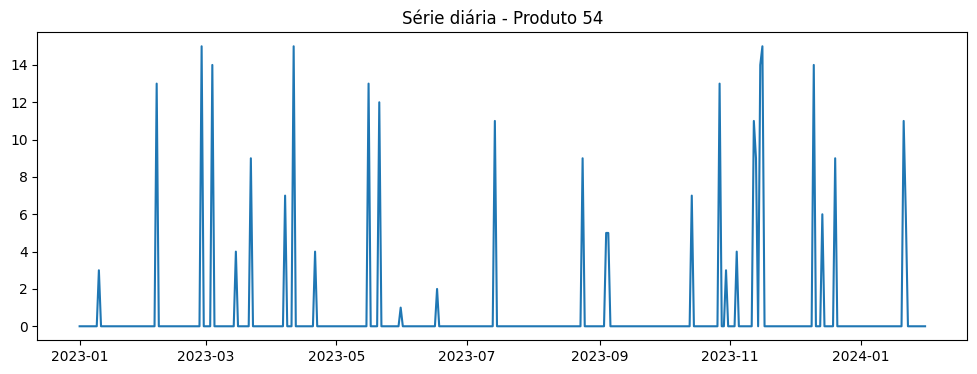

In [31]:
plt.figure(figsize=(12,4))
plt.plot(df_prod_diario)
plt.title('Série diária - Produto 54')
plt.show()

In [32]:
# Criando dataframe final

df_prod_final = (
    df_prod_diario
    .reindex(full_index, fill_value=0)
    .to_frame(name='qtd_real')
    .rename_axis('data')
    .reset_index()
)

df_prod_final

,data,qtd_real
0,2023-01-01,0
1,2023-01-02,0
2,2023-01-03,0
3,2023-01-04,0
4,2023-01-05,0
...,...,...
391,2024-01-27,0
392,2024-01-28,0
393,2024-01-29,0
394,2024-01-30,0


In [33]:
# Modelo de Previsão com Média Móvel de 7 dias

# Extipulando datas de treino e de teste

train = df_prod_diario[:'2023-12-31']
test = df_prod_diario['2024-01-01':'2024-01-31']

predictions = []

# histórico começa com dados reais
history = list(train)

for i in range(len(test)):
    
    # média dos últimos 7 dias
    if len(history) < 7:
        yhat = np.mean(history)
    else:
        yhat = np.mean(history[-7:])
    
    predictions.append(yhat)

    history.append(test.iloc[i])

In [36]:
# Dataframe de resultados
df_janeiro2024 = df_prod_final[df_prod_final['data'] >= '2024-01-01'].copy()
df_janeiro2024['previsao'] = predictions

# Cállculo do MAE
mae = mean_absolute_error(df_janeiro2024['qtd_real'], df_janeiro2024['previsao'])

# Soma da primeira semana
soma_semana = df_janeiro2024[df_janeiro2024['data'] <= '2024-01-07']['previsao'].sum()

# Resultados
print(df_janeiro2024[['data', 'qtd_real', 'previsao']].to_string())
print(f"\nMAE: {mae:.4f}")
print(f"\nSoma prevista primeira semana: {round(soma_semana)}")

          data  qtd_real  previsao
365 2024-01-01         0  0.000000
366 2024-01-02         0  0.000000
367 2024-01-03         0  0.000000
368 2024-01-04         0  0.000000
369 2024-01-05         0  0.000000
370 2024-01-06         0  0.000000
371 2024-01-07         0  0.000000
372 2024-01-08         0  0.000000
373 2024-01-09         0  0.000000
374 2024-01-10         0  0.000000
375 2024-01-11         0  0.000000
376 2024-01-12         0  0.000000
377 2024-01-13         0  0.000000
378 2024-01-14         0  0.000000
379 2024-01-15         0  0.000000
380 2024-01-16         0  0.000000
381 2024-01-17         0  0.000000
382 2024-01-18         0  0.000000
383 2024-01-19         0  0.000000
384 2024-01-20         0  0.000000
385 2024-01-21        11  0.000000
386 2024-01-22         6  1.571429
387 2024-01-23         0  2.428571
388 2024-01-24         0  2.428571
389 2024-01-25         0  2.428571
390 2024-01-26         0  2.428571
391 2024-01-27         0  2.428571
392 2024-01-28      

## Questão 8 - Sistema de recomendação

**Cenário**

A Marina percebeu que clientes que compram lanchas quase sempre esquecem de levar a defensa (proteção lateral). Ela quer implementar uma vitrine de "Quem comprou isso, também levou..." no site. 

Como não temos ferramentas de Big Data caras, você precisará criar um motor de recomendação, baseado na similaridade de compra dos clientes. 

Identificar qual produto deve ser recomendado junto ao item “GPS Garmin Vortex Maré Drift”, com base na similaridade de comportamento de compra dos clientes.


**Tarefa:**
1. Crie uma matriz de interação Usuário × Produto obedecendo às regras abaixo:
     - a. Linhas: id_cliente
     - b. Colunas: id_produto
     - c. Valor da célula:
     - . 1 se o cliente comprou ao menos uma vez o produto
     - . 0 caso contrário
     - . Ignore a quantidade comprada (presença/ ausência apenas)
2. Cálculo de Similaridade entre Produtos
     - a. Calcule a Similaridade de Cosseno (Cosine Similarity) entre os vetores dos produtos
     - b. A similaridade deve ser calculada produto × produto, com base nos clientes que compraram cada item
3. Ranking de Produtos Similares
     - a. Considere o produto “GPS Garmin Vortex Maré Drift” como item de referência
     - b. Gere um ranking com os 5 produtos mais similares a ele
     - c. Desconsidere o próprio GPS no ranking

In [44]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

In [41]:
# carregando os dados
df_vendas = pd.read_csv('vendas_corrigidas.csv')
df_produtos = pd.read_csv('produtos_cleaned.csv')

# merge para ter nomes dos produtos
df = df_vendas.merge(df_produtos, left_on='id_product', right_on='code')

# criar coluna binária (presença)
df['comprou'] = 1

# matriz usuário x produto
matriz_user_product = df.pivot_table(
    index='id_client',
    columns='id_product',
    values='comprou',
    aggfunc='max',   # garante 1 mesmo com múltiplas compras
    fill_value=0
)

In [66]:
# Check

matriz_user_product

id_product,1,2,3,4,5,6,7,8,9,10,...,141,142,143,144,145,146,147,148,149,150
id_client,,,,,,,,,,,,,,,,,,,,,
1,1,0,1,1,1,1,0,0,0,0,...,1,1,0,1,1,1,1,1,0,0
2,0,1,1,0,1,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
3,1,1,1,1,1,1,1,0,1,1,...,0,1,1,1,0,1,1,1,1,1
4,1,1,0,1,1,0,1,0,0,1,...,1,1,1,1,0,0,1,0,1,1
5,1,1,0,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,1,1,0
6,1,0,1,0,1,1,1,0,1,0,...,0,1,1,1,1,0,1,1,1,1
7,1,1,1,0,0,1,1,0,1,1,...,0,1,1,1,1,1,1,1,1,1
8,1,1,1,1,1,1,1,1,1,0,...,1,1,0,1,1,0,1,0,1,1
9,1,1,0,1,1,0,1,1,0,1,...,1,1,1,0,1,1,1,1,1,1


In [67]:
# Transpondo a matriz (produtos como linhas, pois queremos similaridade entre produtos)
matriz_produto = matriz_user_product.T

# Calculando a Similaridade DE cosseno entre todos os pares de produtos
similaridade = cosine_similarity(matriz_produto)

# Transforma em dataframe para facilitar a leitura
df_similaridade = pd.DataFrame(
    similaridade,
    index=matriz_produto.index,
    columns=matriz_produto.index
)

print(df_similaridade.shape)
df_similaridade

(150, 150)


id_product,1,2,3,4,5,6,7,8,9,10,...,141,142,143,144,145,146,147,148,149,150
id_product,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.775058,0.737865,0.810191,0.748331,0.769484,0.775058,0.727825,0.711512,0.698771,...,0.795133,0.753819,0.775058,0.769484,0.721605,0.775058,0.872082,0.721605,0.727825,0.775058
2,0.775058,1.000000,0.704295,0.757865,0.714286,0.712931,0.771429,0.750290,0.788811,0.687256,...,0.795192,0.778078,0.771429,0.767772,0.685714,0.742857,0.712931,0.628571,0.750290,0.742857
3,0.737865,0.704295,1.000000,0.800641,0.704295,0.865181,0.732467,0.712396,0.777778,0.707107,...,0.675923,0.739795,0.732467,0.757033,0.704295,0.788811,0.729996,0.732467,0.739795,0.704295
4,0.810191,0.757865,0.800641,1.000000,0.757865,0.753310,0.757865,0.789747,0.773953,0.735980,...,0.831239,0.789747,0.730798,0.779287,0.730798,0.730798,0.805263,0.757865,0.763422,0.757865
5,0.748331,0.714286,0.704295,0.757865,1.000000,0.795192,0.742857,0.694713,0.760639,0.627495,...,0.795192,0.722501,0.714286,0.685511,0.685714,0.714286,0.767772,0.657143,0.722501,0.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,0.775058,0.742857,0.788811,0.730798,0.714286,0.767772,0.714286,0.722501,0.760639,0.627495,...,0.712931,0.722501,0.714286,0.740351,0.714286,1.000000,0.712931,0.771429,0.722501,0.657143
147,0.872082,0.712931,0.729996,0.805263,0.767772,0.763158,0.767772,0.720064,0.702959,0.688247,...,0.789474,0.720064,0.795192,0.763158,0.740351,0.712931,1.000000,0.685511,0.746733,0.795192
148,0.721605,0.628571,0.732467,0.757865,0.657143,0.767772,0.685714,0.750290,0.788811,0.687256,...,0.685511,0.805867,0.714286,0.767772,0.771429,0.771429,0.685511,1.000000,0.750290,0.714286


In [68]:
# Encontrando o id do produto de referência
id_gps = df_produtos[df_produtos['name'] == 'GPS Garmin Vortex Maré Drift']['code'].values[0]

id_gps

27

In [70]:
# Criando o ranking
ranking = df_similaridade[id_gps].sort_values(ascending=False)

# Removendo o próprio produto (id_gps)
ranking = ranking.drop(id_gps)

# Transformando em DataFrame
ranking = ranking.reset_index()

# Dando nomes para as colunas
ranking.columns = ['id_product', 'similaridade']

ranking

,id_product,similaridade
0,94,0.869626
1,11,0.868037
2,35,0.853913
3,115,0.850000
4,1,0.850000
...,...,...
144,60,0.688102
145,120,0.688102
146,43,0.675303
147,75,0.675303


In [71]:
# Apenas os 5 primeiros
ranking_top5 = ranking.head(5)

ranking_top5

,id_product,similaridade
0,94,0.869626
1,11,0.868037
2,35,0.853913
3,115,0.850000
4,1,0.850000


In [72]:
# Trazendo o nome dos produtos

ranking_top5 = ranking_top5.merge(df_produtos[['code', 'name']], left_on='id_product', right_on='code').drop(columns='code')

print(ranking_top5[['id_product', 'name', 'similaridade']])

   id_product                                        name  similaridade
0          94            Motor de Popa Volvo Magnum 276HP      0.869626
1          11         GPS Furuno Swift Leviathan Poseidon      0.868037
2          35                          Radar Furuno Swift      0.853913
3         115  Cabo de Nylon Delta Force Magnum Leviathan      0.850000
4           1                 Transponder AIS Maré Magnum      0.850000
